In [245]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install lmfit
from lmfit.models import GaussianModel

In [246]:
# Load each Raman spectrum from its sheet
log_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_log_mean raman')
sta_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name='ec_sta_mean raman')
ref_df = pd.read_excel("Copy_of_Ecol_Raman.xlsx", sheet_name="tbl_15components")

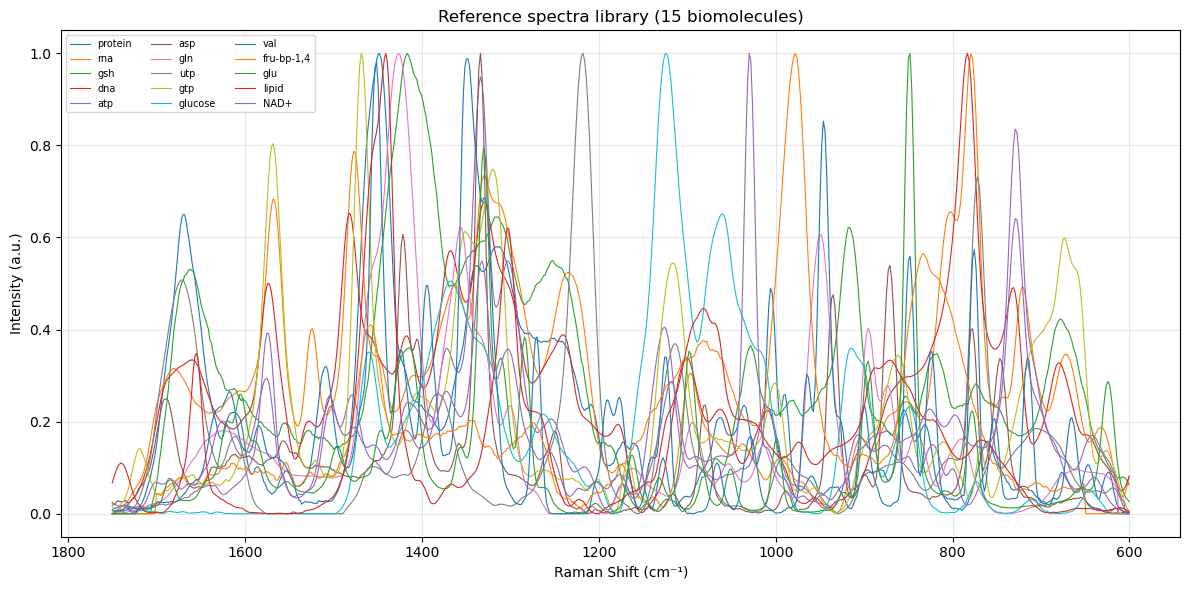

In [247]:
wn = ref_df["wavenumber"].values
ref_names = [col for col in ref_df.columns if col != "wavenumber"]

plt.figure(figsize=(12, 6))
for name in ref_names:
    plt.plot(wn, ref_df[name], linewidth=0.8, label=name)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference spectra library (15 biomolecules)")
plt.legend(fontsize=7, ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

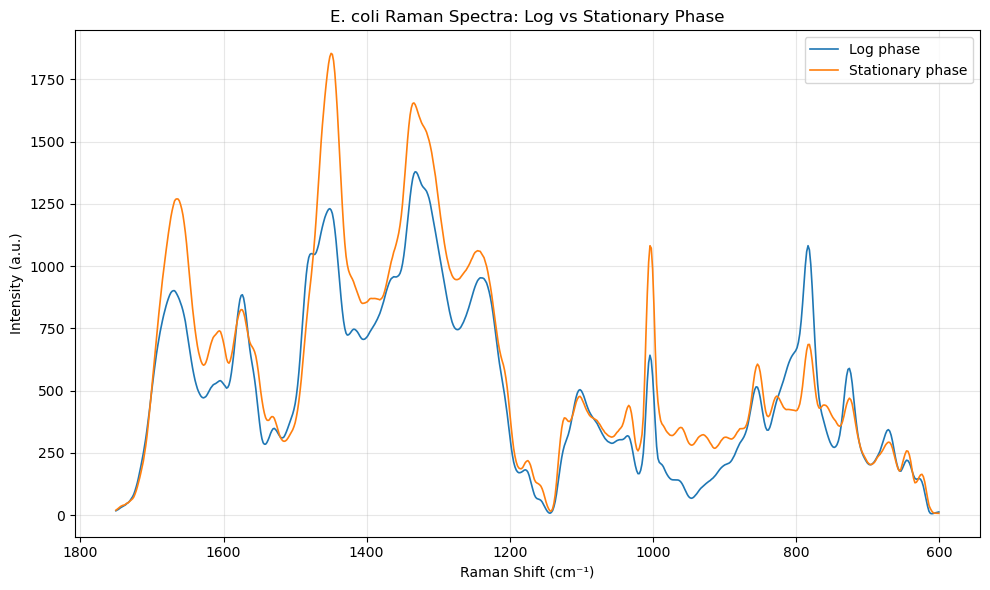

In [248]:

# Standardise column names (first two columns are wavenumber + intensity)
log_df = log_df.iloc[:, :2]
sta_df = sta_df.iloc[:, :2]

log_df.columns = ["wavenumber", "intensity"]
sta_df.columns = ["wavenumber", "intensity"]

# Sort just in case
log_df = log_df.sort_values("wavenumber")
sta_df = sta_df.sort_values("wavenumber")

# Plot both on one graph
plt.figure(figsize=(10,6))
plt.plot(log_df["wavenumber"], log_df["intensity"], label="Log phase", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity"], label="Stationary phase", linewidth=1.2)

# Reverse x-axis (Raman convention)
plt.gca().invert_xaxis()

plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("E. coli Raman Spectra: Log vs Stationary Phase")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [267]:
# Nyquist criterion for Raman
dnu = np.mean(np.diff(x))  # wavenumber spacing
Delta_nu = x.max() - x.min()  # total wavenumber range

# Fourier conjugate spacing
Delta_t = 1.0 / dnu  # range in Fourier space (from sampling theorem)

N_ind = (2.0 / np.pi) * Delta_nu * Delta_t

print(f"Wavenumber spacing dν = {dnu:.4f} cm⁻¹")
print(f"Wavenumber range Δν = {Delta_nu:.2f} cm⁻¹")
print(f"Fourier range Δt = 1/dν = {Delta_t:.4f} cm")
print(f"N_ind = (2/π) × Δν × Δt = {N_ind:.1f}")
print(f"N_data = {len(x)}")

Wavenumber spacing dν = 1.8085 cm⁻¹
Wavenumber range Δν = 1150.21 cm⁻¹
Fourier range Δt = 1/dν = 0.5529 cm
N_ind = (2/π) × Δν × Δt = 404.9
N_data = 637


## Now we normalise so that the peak fitting is numerically stable

In [252]:
# Normalise intensities so max = 1
log_df["intensity_norm"] = log_df["intensity"] / log_df["intensity"].max()
sta_df["intensity_norm"] = sta_df["intensity"] / sta_df["intensity"].max()

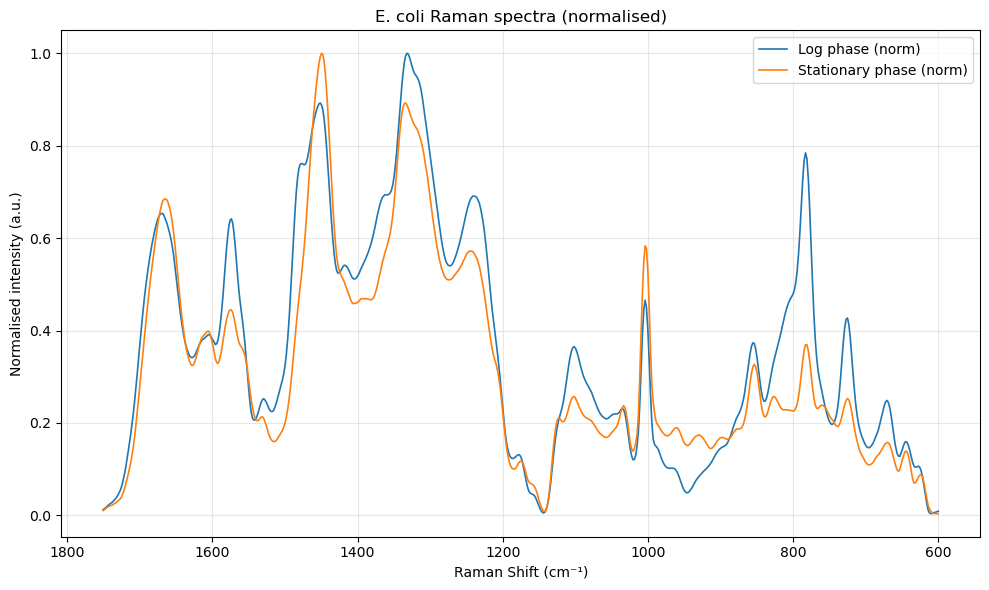

In [253]:
# Plotting with normalised data

plt.figure(figsize=(10, 6))
plt.plot(log_df["wavenumber"], log_df["intensity_norm"], label="Log phase (norm)", linewidth=1.2)
plt.plot(sta_df["wavenumber"], sta_df["intensity_norm"], label="Stationary phase (norm)", linewidth=1.2)

plt.gca().invert_xaxis()
plt.xlabel("Raman Shift (cm⁻¹)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("E. coli Raman spectra (normalised)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The peaks are noticeably more defined now, especially for the log phase data.

In [254]:
x = log_df["wavenumber"].values
y = log_df["intensity_norm"].values

ref_names = [col for col in ref_df.columns if col != "wavenumber"]
R = ref_df[ref_names].values

# Reference spectra are in descending wavenumber order, data is ascending — flip to match
ref_df = ref_df.iloc[::-1].reset_index(drop=True)
R = ref_df[ref_names].values

Detected peaks: 20
Settings used:
  window: 600-1800 cm^-1
  baseline: AsLS (lam=1e+05, p=0.005)  | used_for_detection=True
  smoothing: True (sg_window=11, sg_poly=3)
  min_sep_cm1=1.0 -> distance_pts=1 (dx≈1.805 cm^-1)
  height_frac=0.0001 -> height=6.62e-05
  prom_frac=0.0005 -> prominence=0.000331


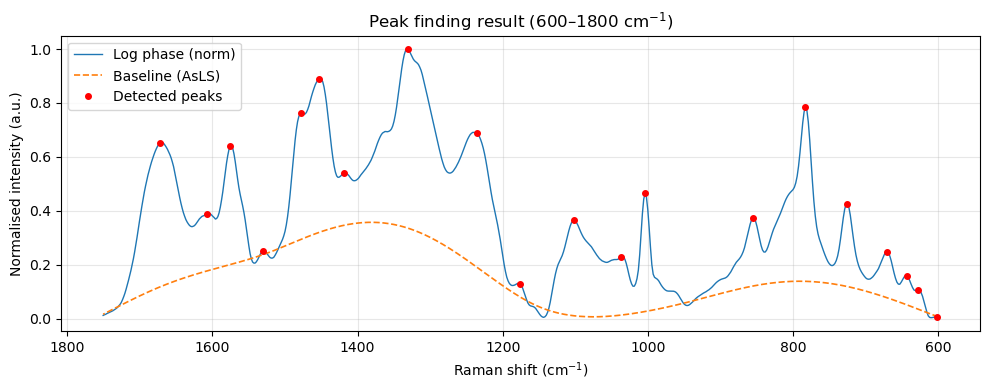


Top 20 peaks by prominence:
 1.  1330.42 cm^-1   prominence=0.6654
 2.   783.08 cm^-1   prominence=0.6346
 3.  1671.93 cm^-1   prominence=0.5338
 4.  1004.02 cm^-1   prominence=0.4194
 5.  1453.18 cm^-1   prominence=0.4124
 6.  1575.41 cm^-1   prominence=0.2556
 7.  1101.78 cm^-1   prominence=0.2544
 8.   725.26 cm^-1   prominence=0.2337
 9.  1235.95 cm^-1   prominence=0.2188
10.   855.63 cm^-1   prominence=0.1281
11.   670.85 cm^-1   prominence=0.1204
12.   643.48 cm^-1   prominence=0.0345
13.  1607.74 cm^-1   prominence=0.0262
14.  1176.45 cm^-1   prominence=0.0242
15.  1037.38 cm^-1   prominence=0.0144
16.  1530.91 cm^-1   prominence=0.0109
17.  1418.34 cm^-1   prominence=0.0102
18.  1477.46 cm^-1   prominence=0.0044
19.   602.21 cm^-1   prominence=0.0024
20.   627.79 cm^-1   prominence=0.0005


In [255]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy import sparse
from scipy.sparse.linalg import spsolve

def baseline_asls(y, lam=1e6, p=0.01, niter=10):
    """Asymmetric least-squares baseline estimate."""
    y = np.asarray(y)
    L = y.size
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)
    for _ in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.T)
        z = spsolve(Z, w * y)
        w = p * (y > z) + (1 - p) * (y < z)
    return z

# =============================
# EASY-TO-ADJUST SETTINGS
# =============================
xmin, xmax = 600, 1800          # analysis window

use_smoothing = True
sg_window = 11                  # must be odd; 11/15/21...
sg_poly   = 3

# "Strict" = reject noise bumps; if you want *more* small bumps, lower prom/height
min_sep_cm1  = 1.0              # strict separation (cm^-1)
height_frac  = 0.0001           # strict height floor (fraction of max)
prom_frac    = 0.0005           # strict prominence (fraction of max)

# Baseline fit (shown on plot; used for detection signal only)
use_baseline_for_detection = True
lam = 1e5                        # increase -> straighter baseline; decrease -> more curved
p   = 0.005                      # smaller -> baseline sits more under peaks

# =============================
# 1) Window the spectrum
# =============================
mask = (x >= xmin) & (x <= xmax)
x_use = x[mask]
y_use = y[mask]

# Ensure x increases for robust distance conversion
if x_use[0] > x_use[-1]:
    orderx = np.argsort(x_use)
    x_use = x_use[orderx]
    y_use = y_use[orderx]

# =============================
# 2) Baseline fit (not subtracted in plot)
# =============================
base = baseline_asls(y_use, lam=lam, p=p, niter=10)

# =============================
# 3) Detection signal (baseline-detrended, optional smoothing)
# =============================
y_det = (y_use - base) if use_baseline_for_detection else y_use
y_det = np.clip(y_det, 0, None)

if use_smoothing and len(y_det) >= sg_window:
    w = sg_window if sg_window % 2 == 1 else sg_window + 1
    w = min(w, len(y_det) if len(y_det) % 2 == 1 else len(y_det) - 1)
    y_det = savgol_filter(y_det, window_length=w, polyorder=min(sg_poly, w-2))

# =============================
# 4) Convert min separation (cm^-1) -> points
# =============================
dx = float(np.median(np.diff(x_use)))
distance_pts = int(np.ceil(min_sep_cm1 / dx))

# =============================
# 5) Peak finding (scaled thresholds)
# =============================
ymax = float(np.max(y_det))
height = height_frac * ymax
prominence = prom_frac * ymax

peaks, props = find_peaks(
    y_det,
    height=height,
    prominence=prominence,
    distance=distance_pts
)

peak_pos  = x_use[peaks]
peak_y    = y_use[peaks]               # markers on original spectrum
peak_prom = props["prominences"]

print(f"Detected peaks: {len(peaks)}")
print("Settings used:")
print(f"  window: {xmin}-{xmax} cm^-1")
print(f"  baseline: AsLS (lam={lam:.2g}, p={p})  | used_for_detection={use_baseline_for_detection}")
print(f"  smoothing: {use_smoothing} (sg_window={sg_window}, sg_poly={sg_poly})")
print(f"  min_sep_cm1={min_sep_cm1} -> distance_pts={distance_pts} (dx≈{dx:.3f} cm^-1)")
print(f"  height_frac={height_frac} -> height={height:.3g}")
print(f"  prom_frac={prom_frac} -> prominence={prominence:.3g}")

# =============================
# 6) Plot (spectrum + baseline + peaks)
# =============================
plt.figure(figsize=(10, 4))
plt.plot(x_use, y_use, linewidth=1, label="Log phase (norm)")
plt.plot(x_use, base, "--", linewidth=1.2, label="Baseline (AsLS)")
plt.plot(peak_pos, peak_y, "ro", markersize=4, label="Detected peaks")
plt.gca().invert_xaxis()
plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("Normalised intensity (a.u.)")
plt.title("Peak finding result (600–1800 cm$^{-1}$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =============================
# 7) Sort peaks by prominence (for initial centres later)
# =============================
order = np.argsort(peak_prom)[::-1]
peak_pos_sorted  = peak_pos[order]
peak_prom_sorted = peak_prom[order]
peak_y_sorted    = peak_y[order]

top_n = min(20, len(peak_pos_sorted))
print(f"\nTop {top_n} peaks by prominence:")
for i in range(top_n):
    print(f"{i+1:>2}. {peak_pos_sorted[i]:8.2f} cm^-1   prominence={peak_prom_sorted[i]:.4f}")


# Fitting and BFI

## Log Spectra Fitting

Forward selection: adding biomolecules by BFI
n=637, baseline_deg=2
Priors: Δb=4.0, ΔA=1.0, coeffs>=0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   3.070e+01  4.842e-02     48.1324          -
   1             dna   4     4   6.52e+00   7.866e+00  1.243e-02    477.0149   428.8825
   2         protein   5     5   7.85e+00   2.502e+00  3.958e-03    836.3239   359.3090
   3             rna   6     6   1.95e+01   1.567e+00  2.484e-03    981.2392   144.9153
   4             gsh   7     7   2.02e+01   1.344e+00  2.133e-03   1026.2102    44.9710
   5             atp   8     8   2.04e+01   1.205e+00  1.915e-03   1057.0986    30.8884
   6             utp   9     9   2.06e+01   1.153e+00  1.836e-03   1067.3394    10.2409
   7             gtp  10    10   2.15e+01   1.112e+00  1.774e-03   1075.0306     7.6912
   8         g

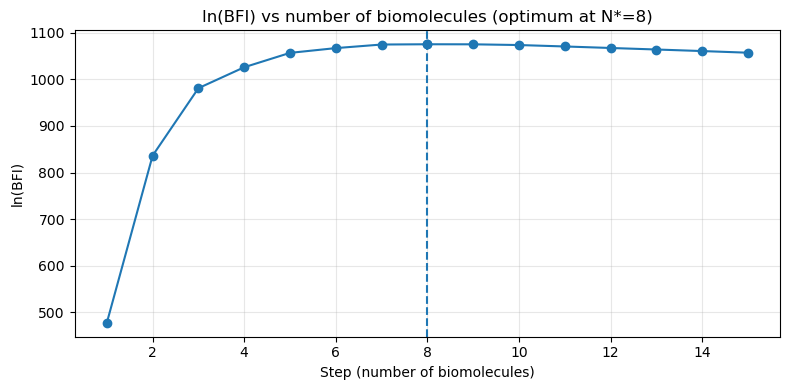

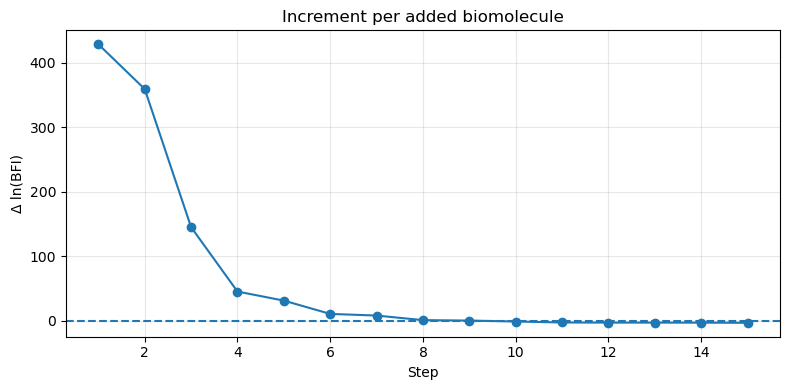

In [256]:
from scipy.optimize import lsq_linear

# ===========================
# SETTINGS
# ===========================
baseline_deg = 2
bmax = 2.0
Amax = 1.0  # prior width for biomolecule coefficients (max-normalised data, so coeffs ~ 0-1)

n = len(x)
n_base = baseline_deg + 1

def x_scaled(x):
    return 2*(x - x.min())/(x.max() - x.min()) - 1.0

def build_X(x, ref_matrix, selected_idx, deg):
    xs = x_scaled(x)
    B = np.vstack([xs**i for i in range(deg+1)]).T
    if len(selected_idx) > 0:
        S = ref_matrix[:, selected_idx]
    else:
        S = np.zeros((len(x), 0))
    return np.hstack([B, S])

def fit_nonneg(X, y, n_base):
    k = X.shape[1]
    lb = np.full(k, -np.inf)
    ub = np.full(k,  np.inf)
    lb[n_base:] = 0.0  # biomolecule coefficients >= 0

    res = lsq_linear(X, y, bounds=(lb, ub), lsmr_tol='auto', verbose=0)
    beta = res.x
    yhat = X @ beta
    r = y - yhat
    RSS = float(np.sum(r**2))

    dof = max(n - k, 1)
    s2 = RSS / dof

    XtX = X.T @ X
    try:
        XtX_inv = np.linalg.inv(XtX)
    except np.linalg.LinAlgError:
        XtX_inv = np.linalg.pinv(XtX)

    cov = s2 * XtX_inv
    condX = float(np.linalg.cond(X))
    rank = np.linalg.matrix_rank(X)
    return beta, yhat, RSS, s2, cov, rank, condX

def ln_bfi(s2, cov, prior_widths, n, k):
    dof = n - k
    if dof <= 0 or s2 <= 0 or not np.isfinite(s2):
        return np.nan

    sign, logdet = np.linalg.slogdet(cov)
    if sign != 1 or not np.isfinite(logdet):
        return np.nan

    ll = (-0.5 * n * np.log(2*np.pi)
          -0.5 * n * np.log(s2)
          -0.5 * dof)

    occam = (0.5 * k * np.log(2*np.pi)
             +0.5 * logdet)

    prior = -np.sum(np.log(prior_widths))

    return float(ll + occam + prior)

# ---------- baseline-only start ----------
selected = []
history = []

X0 = build_X(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, cov0, rank0, cond0 = fit_nonneg(X0, y, n_base)
prior0 = np.array([2*bmax]*n_base, float)
lnB0 = ln_bfi(s20, cov0, prior0, n=n, k=X0.shape[1])
prev_lnB = lnB0

print("Forward selection: adding biomolecules by BFI")
print(f"n={n}, baseline_deg={baseline_deg}")
print(f"Priors: Δb={2*bmax}, ΔA={Amax}, coeffs>=0")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"{0:>4d}  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {cond0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnB0:>10.4f}  {'-':>9s}")

candidates = list(range(R.shape[1]))  # indices 0..14

for step in range(1, R.shape[1] + 1):
    best = None

    for idx in candidates:
        if idx in selected:
            continue

        try_selected = selected + [idx]
        X = build_X(x, R, try_selected, baseline_deg)
        beta, yhat, RSS, s2, cov, rank, condX = fit_nonneg(X, y, n_base)

        prior = np.array([2*bmax]*n_base + [Amax]*len(try_selected), float)
        lnB = ln_bfi(s2, cov, prior, n=n, k=X.shape[1])

        if not np.isfinite(lnB):
            continue

        dlnB = lnB - prev_lnB
        if (best is None) or (dlnB > best[0]):
            best = (dlnB, lnB, idx, X.shape[1], rank, condX, RSS, s2, yhat, beta)

    if best is None:
        print("\nNo valid candidates remaining.")
        break

    dlnB, lnB, idx_best, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best, beta_best = best
    selected.append(idx_best)
    history.append((step, idx_best, ref_names[idx_best], lnB, dlnB, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best, beta_best))

    print(f"{step:>4d}  {ref_names[idx_best]:>14s}  {k_best:>2d}  {rank_best:>4d}  {cond_best:>9.2e}  {RSS_best:>10.3e}  {s2_best:>9.3e}  {lnB:>10.4f}  {dlnB:>9.4f}")
    prev_lnB = lnB

# ---- find optimum
steps = np.array([h[0] for h in history], int)
lnBFI_arr = np.array([h[3] for h in history], float)
dln_arr = np.array([h[4] for h in history], float)

best_idx = int(np.nanargmax(lnBFI_arr))
N_star = int(steps[best_idx])
ln_star = float(lnBFI_arr[best_idx])

print(f"\nOptimal model: N* = {N_star} biomolecules at lnBFI = {ln_star:.4f}")
print("Selected (in order):", [ref_names[h[1]] for h in history[:N_star]])

# ---- plots
plt.figure(figsize=(8,4))
plt.plot(steps, lnBFI_arr, marker="o")
plt.axvline(N_star, linestyle="--")
plt.scatter([N_star], [ln_star], zorder=5)
plt.xlabel("Step (number of biomolecules)")
plt.ylabel("ln(BFI)")
plt.title(f"ln(BFI) vs number of biomolecules (optimum at N*={N_star})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(steps, dln_arr, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δ ln(BFI)")
plt.title("Increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

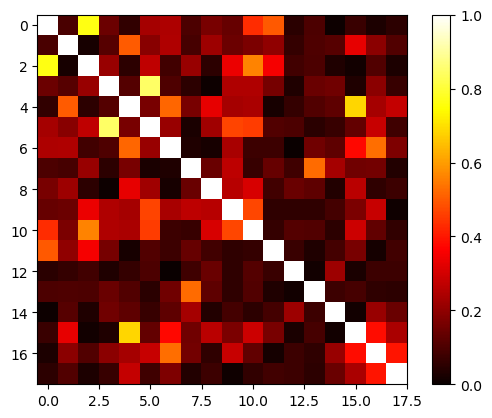

In [257]:
corr_matrix = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
plt.imshow(np.abs(corr_matrix), cmap='hot', vmin=0, vmax=1)
plt.colorbar()

In [258]:
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(f"Optimal number of biomolecules: N* = {N_star}")
print(f"Maximum ln(BFI): {ln_star:.2f}")
print(f"Data points: n = {n}")
print(f"Baseline degree: {baseline_deg}")

best_entry = history[best_idx]
k_best = best_entry[5]
RSS_best = best_entry[8]
s2_best = best_entry[9]

print(f"\nModel at N* = {N_star}:")
print(f"  Total parameters: k = {k_best}")
print(f"  Baseline parameters: {n_base}")
print(f"  Biomolecule coefficients: {N_star}")
print(f"  RSS: {RSS_best:.4f}")
print(f"  s² = RSS/(n-k): {s2_best:.6f}")

print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star):
    print(f"  {i+1}. {history[i][2]}")


FINAL RESULTS SUMMARY
Optimal number of biomolecules: N* = 8
Maximum ln(BFI): 1075.61
Data points: n = 637
Baseline degree: 2

Model at N* = 8:
  Total parameters: k = 11
  Baseline parameters: 3
  Biomolecule coefficients: 8
  RSS: 1.0979
  s² = RSS/(n-k): 0.001754

Selected biomolecules (in order of selection):
  1. dna
  2. protein
  3. rna
  4. gsh
  5. atp
  6. utp
  7. gtp
  8. glucose


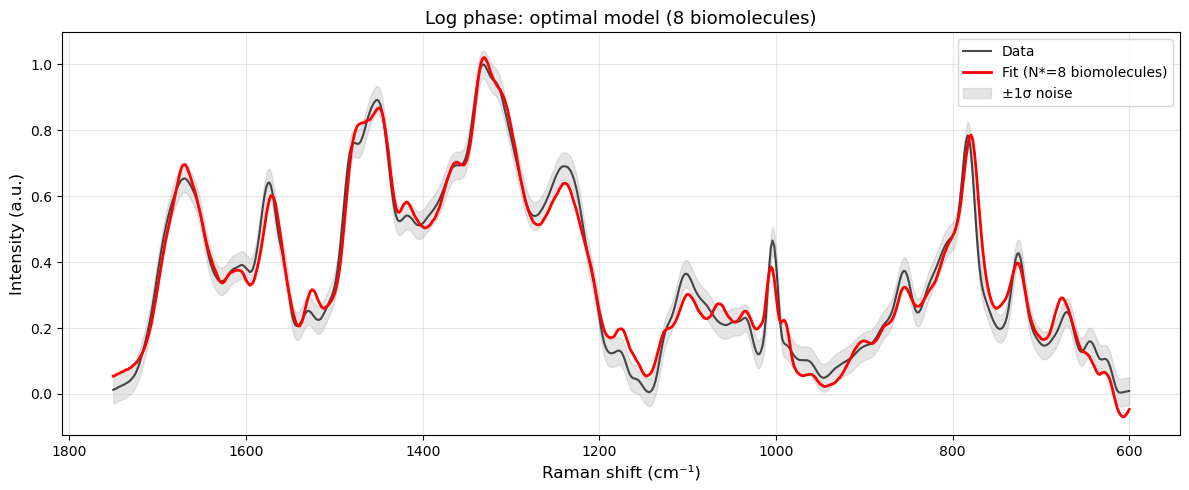

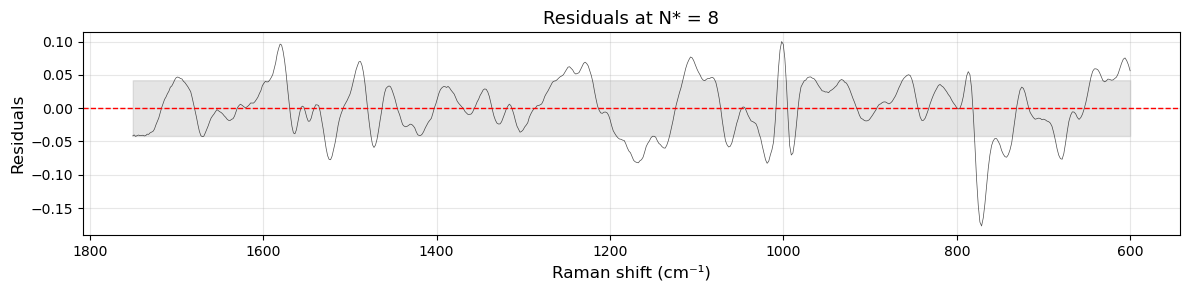

In [259]:
yhat_best = history[best_idx][10]
residuals = y - yhat_best

plt.figure(figsize=(12, 5))
plt.plot(x, y, 'k-', linewidth=1.5, label='Data', alpha=0.7)
plt.plot(x, yhat_best, 'r-', linewidth=2, label=f'Fit (N*={N_star} biomolecules)')
plt.fill_between(x, y - np.sqrt(s2_best), y + np.sqrt(s2_best), 
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Log phase: optimal model ({N_star} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(x, residuals, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_best), +np.sqrt(s2_best), 
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Residuals at N* = {N_star}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Amplitude analysis

COEFFICIENT ANALYSIS AT N* = 8

Baseline coefficients:
  b0 = -0.0099
  b1 = 0.0849
  b2 = -0.0258

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  dna                  0.3955      24.4%
  protein              0.4751      29.3%
  rna                  0.4092      25.2%
  gsh                  0.1148       7.1%
  atp                  0.0949       5.8%
  utp                  0.0621       3.8%
  gtp                  0.0370       2.3%
  glucose              0.0354       2.2%

  Total: 1.6240


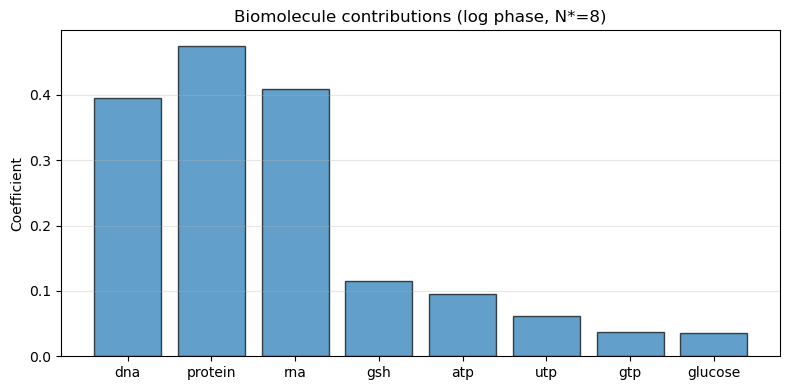

In [260]:
beta_best = history[best_idx][11]
baseline_coeffs = beta_best[:n_base]
coeffs_best = beta_best[n_base:]
selected_names = [history[i][2] for i in range(N_star)]

print("=" * 60)
print(f"COEFFICIENT ANALYSIS AT N* = {N_star}")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total = coeffs_best.sum()
for name, c in zip(selected_names, coeffs_best):
    print(f"  {name:<14s} {c:>12.4f} {c/total*100:>9.1f}%")

print(f"\n  Total: {total:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names, coeffs_best, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (log phase, N*={N_star})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Stationary Data Fitting

Forward selection: STATIONARY PHASE
n=637, baseline_deg=2, Amax=1.0

step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI
------------------------------------------------------------------------------------------
   0      (baseline)   3     3   3.76e+00   2.312e+01  3.647e-02    138.0185          -
   1         protein   4     4   6.54e+00   5.418e+00  8.560e-03    594.9831   456.9645
   2             rna   5     5   7.40e+00   2.093e+00  3.311e-03    892.5893   297.6062
   3             gsh   6     6   8.91e+00   1.561e+00  2.474e-03    981.6344    89.0451
   4             atp   7     7   9.29e+00   1.311e+00  2.080e-03   1033.4080    51.7736
   5             dna   8     8   2.04e+01   1.242e+00  1.974e-03   1047.6111    14.2031
   6             gtp   9     9   2.12e+01   1.186e+00  1.889e-03   1058.4264    10.8153
   7      fru-bp-1,4  10    10   2.18e+01   1.146e+00  1.828e-03   1065.7140     7.2876
   8             utp  11    11   2.20e+01   1.10

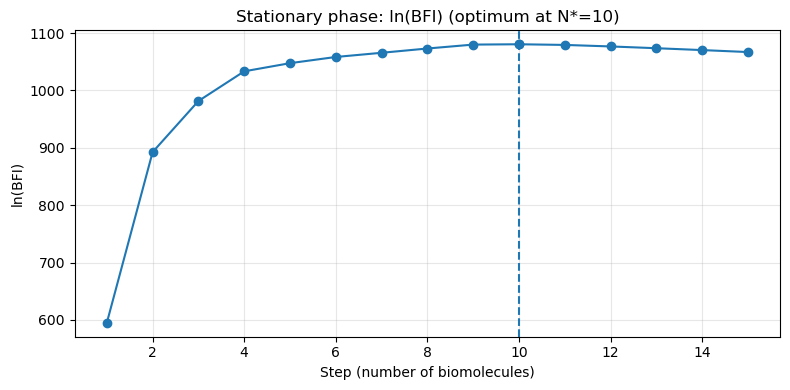

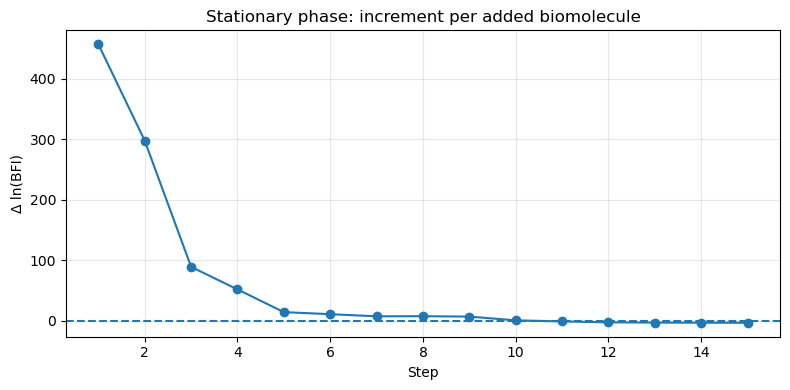

In [261]:
# ===========================
# STATIONARY PHASE: same analysis
# ===========================
y_sta = sta_df["intensity_norm"].values

# Make sure same wavenumber order as reference
if sta_df["wavenumber"].values[0] > sta_df["wavenumber"].values[-1]:
    y_sta = y_sta[::-1]

selected_sta = []
history_sta = []

X0 = build_X(x, R, [], baseline_deg)
beta0, yhat0, RSS0, s20, cov0, rank0, cond0 = fit_nonneg(X0, y_sta, n_base)
prior0 = np.array([2*bmax]*n_base, float)
lnB0 = ln_bfi(s20, cov0, prior0, n=n, k=X0.shape[1])
prev_lnB = lnB0

candidates = list(range(R.shape[1]))

print("Forward selection: STATIONARY PHASE")
print(f"n={n}, baseline_deg={baseline_deg}, Amax={Amax}")
print()
print("step  biomolecule      k  rank  cond(X)        RSS         s²        lnBFI       ΔlnBFI")
print("-" * 90)
print(f"{0:>4d}  {'(baseline)':>14s}  {X0.shape[1]:>2d}  {rank0:>4d}  {cond0:>9.2e}  {RSS0:>10.3e}  {s20:>9.3e}  {lnB0:>10.4f}  {'-':>9s}")

for step in range(1, R.shape[1] + 1):
    best = None
    for idx in candidates:
        if idx in selected_sta:
            continue
        try_selected = selected_sta + [idx]
        X = build_X(x, R, try_selected, baseline_deg)
        beta, yhat, RSS, s2, cov, rank, condX = fit_nonneg(X, y_sta, n_base)
        prior = np.array([2*bmax]*n_base + [Amax]*len(try_selected), float)
        lnB = ln_bfi(s2, cov, prior, n=n, k=X.shape[1])
        if not np.isfinite(lnB):
            continue
        dlnB = lnB - prev_lnB
        if (best is None) or (dlnB > best[0]):
            best = (dlnB, lnB, idx, X.shape[1], rank, condX, RSS, s2, yhat, beta)
    if best is None:
        break
    dlnB, lnB, idx_best, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best, beta_best = best
    selected_sta.append(idx_best)
    history_sta.append((step, idx_best, ref_names[idx_best], lnB, dlnB, k_best, rank_best, cond_best, RSS_best, s2_best, yhat_best, beta_best))
    print(f"{step:>4d}  {ref_names[idx_best]:>14s}  {k_best:>2d}  {rank_best:>4d}  {cond_best:>9.2e}  {RSS_best:>10.3e}  {s2_best:>9.3e}  {lnB:>10.4f}  {dlnB:>9.4f}")
    prev_lnB = lnB

steps_sta = np.array([h[0] for h in history_sta], int)
lnBFI_sta = np.array([h[3] for h in history_sta], float)
dln_sta = np.array([h[4] for h in history_sta], float)

best_idx_sta = int(np.nanargmax(lnBFI_sta))
N_star_sta = int(steps_sta[best_idx_sta])
ln_star_sta = float(lnBFI_sta[best_idx_sta])

print(f"\nOptimal model: N* = {N_star_sta} biomolecules at lnBFI = {ln_star_sta:.4f}")
selected_names_sta = [history_sta[i][2] for i in range(N_star_sta)]
print("Selected (in order):", selected_names_sta)

plt.figure(figsize=(8,4))
plt.plot(steps_sta, lnBFI_sta, marker="o")
plt.axvline(N_star_sta, linestyle="--")
plt.scatter([N_star_sta], [ln_star_sta], zorder=5)
plt.xlabel("Step (number of biomolecules)")
plt.ylabel("ln(BFI)")
plt.title(f"Stationary phase: ln(BFI) (optimum at N*={N_star_sta})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(steps_sta, dln_sta, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Step")
plt.ylabel("Δ ln(BFI)")
plt.title("Stationary phase: increment per added biomolecule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [262]:
# Summary
best_entry_sta = history_sta[best_idx_sta]
k_sta = best_entry_sta[5]
RSS_sta = best_entry_sta[8]
s2_sta = best_entry_sta[9]
yhat_sta = best_entry_sta[10]
beta_sta = best_entry_sta[11]

print("\n" + "="*70)
print("STATIONARY PHASE RESULTS SUMMARY")
print("="*70)
print(f"Optimal number of biomolecules: N* = {N_star_sta}")
print(f"Maximum ln(BFI): {ln_star_sta:.2f}")
print(f"Data points: n = {n}")
print(f"Baseline degree: {baseline_deg}")
print(f"\nModel at N* = {N_star_sta}:")
print(f"  Total parameters: k = {k_sta}")
print(f"  Baseline parameters: {n_base}")
print(f"  Biomolecule coefficients: {N_star_sta}")
print(f"  RSS: {RSS_sta:.4f}")
print(f"  s² = RSS/(n-k): {s2_sta:.6f}")
print(f"\nSelected biomolecules (in order of selection):")
for i in range(N_star_sta):
    print(f"  {i+1}. {history_sta[i][2]}")


STATIONARY PHASE RESULTS SUMMARY
Optimal number of biomolecules: N* = 10
Maximum ln(BFI): 1080.59
Data points: n = 637
Baseline degree: 2

Model at N* = 10:
  Total parameters: k = 13
  Baseline parameters: 3
  Biomolecule coefficients: 10
  RSS: 1.0566
  s² = RSS/(n-k): 0.001693

Selected biomolecules (in order of selection):
  1. protein
  2. rna
  3. gsh
  4. atp
  5. dna
  6. gtp
  7. fru-bp-1,4
  8. utp
  9. asp
  10. val


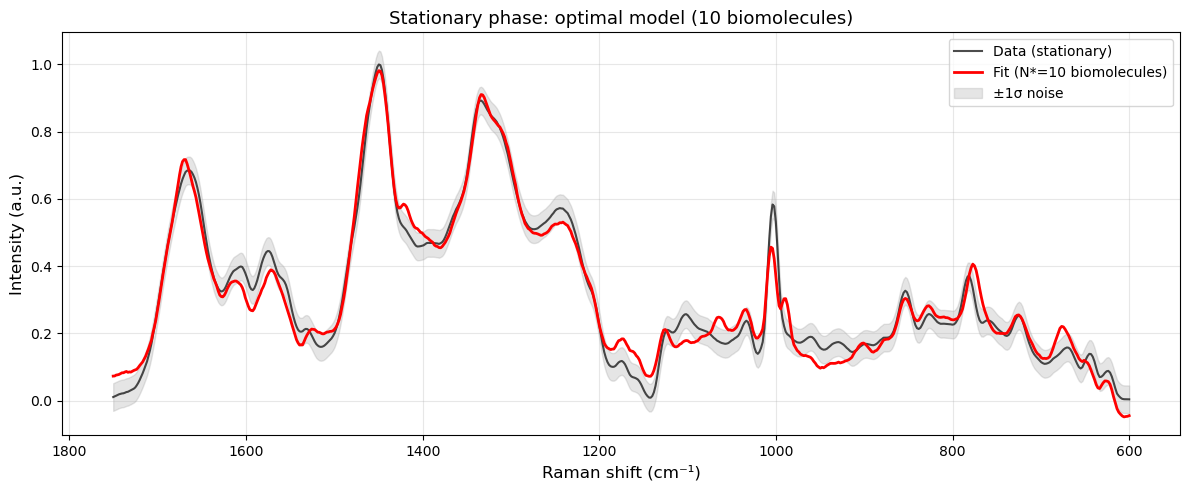

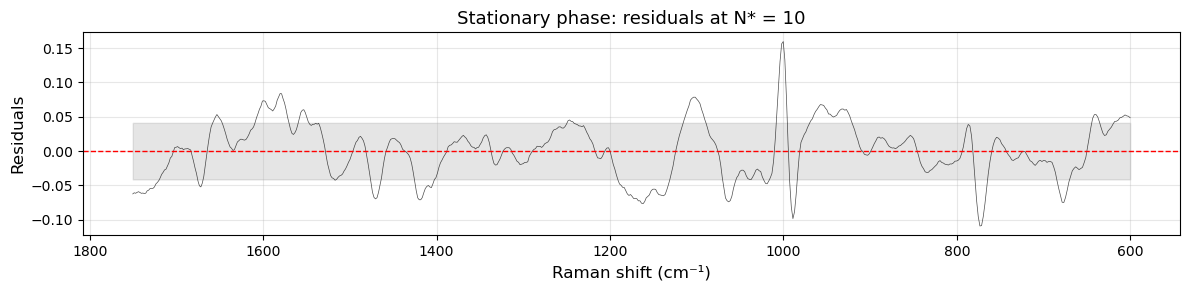

In [263]:
# Fit and residuals
residuals_sta = y_sta - yhat_sta

plt.figure(figsize=(12, 5))
plt.plot(x, y_sta, 'k-', linewidth=1.5, label='Data (stationary)', alpha=0.7)
plt.plot(x, yhat_sta, 'r-', linewidth=2, label=f'Fit (N*={N_star_sta} biomolecules)')
plt.fill_between(x, y_sta - np.sqrt(s2_sta), y_sta + np.sqrt(s2_sta),
                 alpha=0.2, color='gray', label=r'±1σ noise')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Intensity (a.u.)', fontsize=12)
plt.title(f'Stationary phase: optimal model ({N_star_sta} biomolecules)', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(x, residuals_sta, 'k-', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.fill_between(x, -np.sqrt(s2_sta), +np.sqrt(s2_sta),
                 alpha=0.2, color='gray')
plt.gca().invert_xaxis()
plt.xlabel('Raman shift (cm⁻¹)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Stationary phase: residuals at N* = {N_star_sta}', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

STATIONARY PHASE COEFFICIENTS (N* = 10)

Baseline coefficients:
  b0 = 0.0024
  b1 = 0.0728
  b2 = -0.0104

Biomolecule coefficients:
  Biomolecule     Coefficient % of total
----------------------------------------
  protein              0.6735      44.4%
  rna                  0.1867      12.3%
  gsh                  0.1596      10.5%
  atp                  0.1132       7.5%
  dna                  0.1113       7.3%
  gtp                  0.0625       4.1%
  fru-bp-1,4           0.0653       4.3%
  utp                  0.0599       4.0%
  asp                  0.0539       3.6%
  val                  0.0299       2.0%

  Total: 1.5159


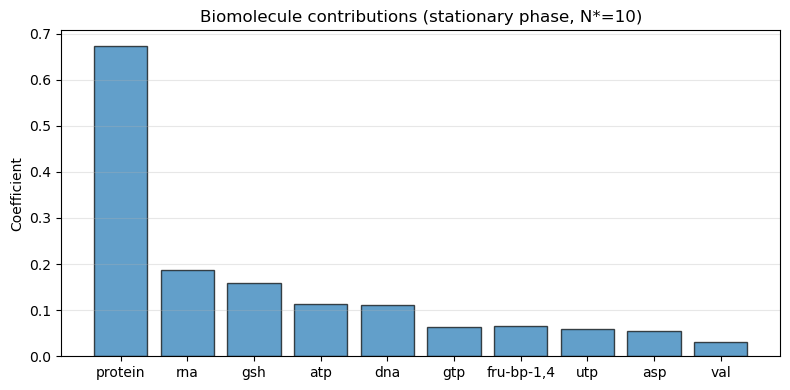

In [264]:
# Coefficient analysis
baseline_coeffs_sta = beta_sta[:n_base]
coeffs_sta = beta_sta[n_base:]

print("=" * 60)
print(f"STATIONARY PHASE COEFFICIENTS (N* = {N_star_sta})")
print("=" * 60)

print(f"\nBaseline coefficients:")
for i, b in enumerate(baseline_coeffs_sta):
    print(f"  b{i} = {b:.4f}")

print(f"\nBiomolecule coefficients:")
print(f"  {'Biomolecule':<14s} {'Coefficient':>12s} {'% of total':>10s}")
print("-" * 40)
total_sta = coeffs_sta.sum()
for name, c in zip(selected_names_sta, coeffs_sta):
    print(f"  {name:<14s} {c:>12.4f} {c/total_sta*100:>9.1f}%")

print(f"\n  Total: {total_sta:.4f}")

plt.figure(figsize=(8, 4))
plt.bar(selected_names_sta, coeffs_sta, edgecolor='black', alpha=0.7)
plt.ylabel('Coefficient')
plt.title(f'Biomolecule contributions (stationary phase, N*={N_star_sta})')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparison of Log and Stationary Phase data

COMPARISON: LOG vs STATIONARY PHASE

  Biomolecule         Log      Sta    Ratio
------------------------------------------
  dna              0.3955   0.1540     0.39
  protein          0.4751   0.6864     1.44
  rna              0.4092   0.1624     0.40
  gsh              0.1148   0.1685     1.47
  atp              0.0949   0.1077     1.13
  utp              0.0621   0.0417     0.67
  gtp              0.0370   0.0698     1.89
  glucose          0.0354   0.0000     0.00


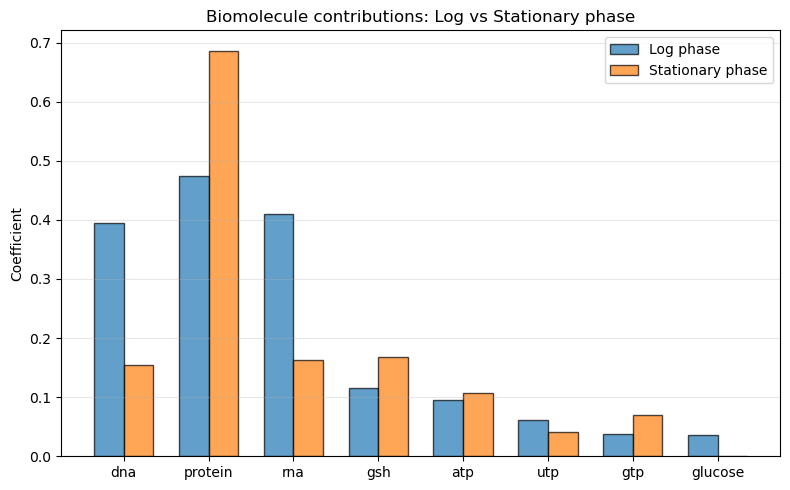

In [265]:
# Stationary phase fit
y_sta = sta_df["intensity_norm"].values

# Make sure same wavenumber order as reference
if sta_df["wavenumber"].values[0] > sta_df["wavenumber"].values[-1]:
    y_sta = y_sta[::-1]

X_sta = build_X(x, R, [h[1] for h in history[:N_star]], baseline_deg)
beta_sta, yhat_sta, RSS_sta, s2_sta, cov_sta, rank_sta, cond_sta = fit_nonneg(X_sta, y_sta, n_base)

coeffs_sta = beta_sta[n_base:]

print("=" * 60)
print("COMPARISON: LOG vs STATIONARY PHASE")
print("=" * 60)
print(f"\n  {'Biomolecule':<14s} {'Log':>8s} {'Sta':>8s} {'Ratio':>8s}")
print("-" * 42)
for i, name in enumerate(selected_names):
    ratio = coeffs_sta[i] / coeffs_best[i] if coeffs_best[i] > 0 else float('inf')
    print(f"  {name:<14s} {coeffs_best[i]:>8.4f} {coeffs_sta[i]:>8.4f} {ratio:>8.2f}")

plt.figure(figsize=(8, 5))
x_pos = np.arange(N_star)
width = 0.35
plt.bar(x_pos - width/2, coeffs_best, width, label='Log phase', edgecolor='black', alpha=0.7)
plt.bar(x_pos + width/2, coeffs_sta, width, label='Stationary phase', edgecolor='black', alpha=0.7)
plt.xticks(x_pos, selected_names)
plt.ylabel('Coefficient')
plt.title('Biomolecule contributions: Log vs Stationary phase')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [266]:
# Union of selected biomolecules from both phases
all_selected = list(dict.fromkeys(selected_names + selected_names_sta))  # preserves order, removes duplicates

# Get coefficients for each phase using their own optimal models
beta_log = history[best_idx][11]
beta_sta_own = history_sta[best_idx_sta][11]

log_idx = [h[1] for h in history[:N_star]]
sta_idx = [h[1] for h in history_sta[:N_star_sta]]

print("=" * 65)
print("FULL COMPARISON: LOG vs STATIONARY PHASE")
print("=" * 65)
print(f"\n  {'Biomolecule':<14s} {'Log':>8s} {'Sta':>8s} {'In Log?':>8s} {'In Sta?':>8s}")
print("-" * 50)

for name in all_selected:
    idx = ref_names.index(name)
    
    if idx in log_idx:
        pos = log_idx.index(idx)
        c_log = beta_log[n_base + pos]
    else:
        c_log = 0.0
    
    if idx in sta_idx:
        pos = sta_idx.index(idx)
        c_sta = beta_sta_own[n_base + pos]
    else:
        c_sta = 0.0
    
    in_log = "yes" if idx in log_idx else "no"
    in_sta = "yes" if idx in sta_idx else "no"
    print(f"  {name:<14s} {c_log:>8.4f} {c_sta:>8.4f} {in_log:>8s} {in_sta:>8s}")

FULL COMPARISON: LOG vs STATIONARY PHASE

  Biomolecule         Log      Sta  In Log?  In Sta?
--------------------------------------------------
  dna              0.3955   0.1113      yes      yes
  protein          0.4751   0.6735      yes      yes
  rna              0.4092   0.1867      yes      yes
  gsh              0.1148   0.1596      yes      yes
  atp              0.0949   0.1132      yes      yes
  utp              0.0621   0.0599      yes      yes
  gtp              0.0370   0.0625      yes      yes
  glucose          0.0354   0.0000      yes       no
  fru-bp-1,4       0.0000   0.0653       no      yes
  asp              0.0000   0.0539       no      yes
  val              0.0000   0.0299       no      yes
